Вам предстоит работать над каталогом мобильных приложений RuStore. В день на модерацию попадают сотни новых приложений. Чтобы пользователи могли легко находить нужное, каждое приложение должно быть привязано к одной или нескольким категориям — например, finance, tools, children, arcade. Сейчас модераторы тратят часы, вручную читая описание и определяя, куда отнести каждое приложение. Это долго, скучно и дорого. Ваша задача — автоматизировать этот процесс: научиться по тексту описания приложения определять его категории.

Что дано
Вам предоставлены тексты приложений в двух вариантах:

full_description — полное описание приложения (если есть);
shortDescription — краткое описание (если есть).
app_name — название приложения;
labels_str — целевые категории, перечисленные через “|”.
Что нужно сделать
По app_name и описаниям для приложений из тестового набора предсказать до трёх категорий, упорядоченных по убыванию уверенности.

Формат ответа
Файл TSV с колонками:

app_name  labels_str


Метрика
Hitrate@3 — если хотя бы одна правильная категория попала в топ-3 предсказаний, считаем это попаданием.
H@3 = (# приложений с попаданием) / (# всех приложений)
- Если приложение имеет 1 правильную метку, и она в топ-3 предсказаний → +1
- Если приложение имеет 2 правильные метки, и хотя бы одна в топ-3 → +1
- Усредняем по всем объектам теста.


**Метрики в нашей задаче**

Для "Мыслим категориями" это **HitRate@3 (H@3)**.

Смысл: попала ли хотя бы одна правильная категория в ваш топ-3? Считаем долю таких объектов:
$$ H@3 = \frac{\text{объекты, где хотя бы одна верная метка в топ-3}}{\text{все объекты}} $$

*Интуитивно*. Если часто заходим хотя бы одной меткой в тройку - метрика высокая.

In [ ]:
def hitrate_at_3(true_labels, pred_top3):
    hits = 0
    for true_labels, top3 in zip(true_labels, pred_top3):
        # есть ли пересечение между множеством истинных меток и предсказанных
        hits += int(any(lbl in top3 for lbl in true_labels))
    return hits / len(true_labels)

In [ ]:
!pip -q install transformers datasets accelerate evaluate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.4 MB/s eta 0:00:00


In [ ]:
# Установка и импорт

import os, json, math, numpy as np, pandas as pd
from dataclasses import dataclass
from collections import Counter
from typing import Optional, Dict, List

import matplotlib.pyplot as plt
import seaborn as sns

import torch
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          DataCollatorWithPadding, TrainingArguments, Trainer)
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split

In [ ]:
# Проверяем подключение к гпу

gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Sat Oct  4 18:06:58 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Настройки для красивых графиков

sns.set_style("whitegrid")
sns.set_palette("viridis")
plt.rcParams.update({'font.size': 12})

### Мини-EDA

Прежде чем писать код модели, самый важный этап - исследовательский анализ данных (`Exploratory Data Analysis`, EDA). Нельзя выбрать правильное решение, не поняв, с чем мы работаем. Именно данные, их структура, особенности и скрытые закономерности диктуют нам, какие модели пробовать, как готовить признаки и какую метрику выбрать. Любой проект в машинном обучении начинается не с `model.fit()`, а с `df.head()` и `df.describe()`.



In [ ]:
from google.colab import drive; drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df_train = pd.read_csv('/content/drive/My Drive/train.tsv', sep='\t')

print("Пример данных:")
df_train

Пример данных:


,app_name,full_description,shortDescription,labels_str
0,Матрона Московская.,Хочешь знать что будет? Загляни в будущие. Мат...,Узнать будущее. Предсказания . Магия волшебног...,lifestyle
1,"Run and Jump - ""Бесконечный раннер""",Run and Jump это новая увлекательная Аркада - ...,Платформенная Аркада - Раннер с захватывающим ...,action|arcade
2,Ghost Maze,"Играя за приведение, собирай необходимые комби...",Игра-головоломка. Попробуй найти выход из лаби...,arcade|puzzle
3,LabTools Mobile: ЛАБОРАТОРНЫЕ ПРИБОРЫ,AR-приложение «LabTools Mobile: Лабораторные п...,AR-приложение которое предназначено для изучен...,education
4,Mario Anime Coloring,\nРаскрасьте своих любимых персонажей из mario...,Раскрасьте своих любимых персонажей из mario я...,children|family
...,...,...,...,...
53489,Yota: мобильная связь,﻿С Yota можно всё!\n\nМожно не беспокоиться – ...,Управляй тарифом и услугами,tools
53490,BTS Musical Player,"Высококачественный музыкальный плеер BTS, мощн...",Музыкальный плеер BTS,tools
53491,Lite Calculator,Lite Calculator - это простое и удобное прилож...,Базовые операции калькулятора,tools
53492,Optiland,Приложение Optiland - многофункциональный серв...,"Для жителей поселков Бристоль, Марсель и Кембридж",tools


Посмотрим отдельно на таргет - целевую переменную.

In [ ]:
expected_cols = {"app_name", "full_description", "shortDescription", "labels_str"}

def parse_labels(s):

    """Преобразует строку вида 'cat1|cat2' в список ['cat1', 'cat2']"""

    if pd.isna(s):
       return []
    return [t.strip() for t in str(s).split("|") if t.strip()]

df_train["labels_list"] = df_train["labels_str"].apply(parse_labels)
df_train["n_labels"] = df_train["labels_list"].apply(len)
all_labels = [label for labels in df_train["labels_list"] for label in labels]
label_counts = Counter(all_labels) # сколько раз встречается каждая уникальная метка

labels_df = (pd.DataFrame({"Категория": list(label_counts.keys()), "Количество": list(label_counts.values())})
             .sort_values("Количество", ascending=False)
             .reset_index(drop=True))
labels_df["Доля_%"] = (labels_df["Количество"] / len(df_train) * 100).round(2)
card_df = (df_train["n_labels"].value_counts().sort_index()
           .rename_axis("Категорий на приложение").reset_index(name="Количество приложений"))
card_df["Доля_%"] = (card_df["Количество приложений"] / len(df_train) * 100).round(2)

print(f"Всего приложений в датасете: {len(df_train)}")
print(f"Всего уникальных категорий: {labels_df.shape[0]}")
print(f"Среднее число категорий на приложение: {df_train['n_labels'].mean():.2f}")

Всего приложений в датасете: 53494
Всего уникальных категорий: 45
Среднее число категорий на приложение: 1.19


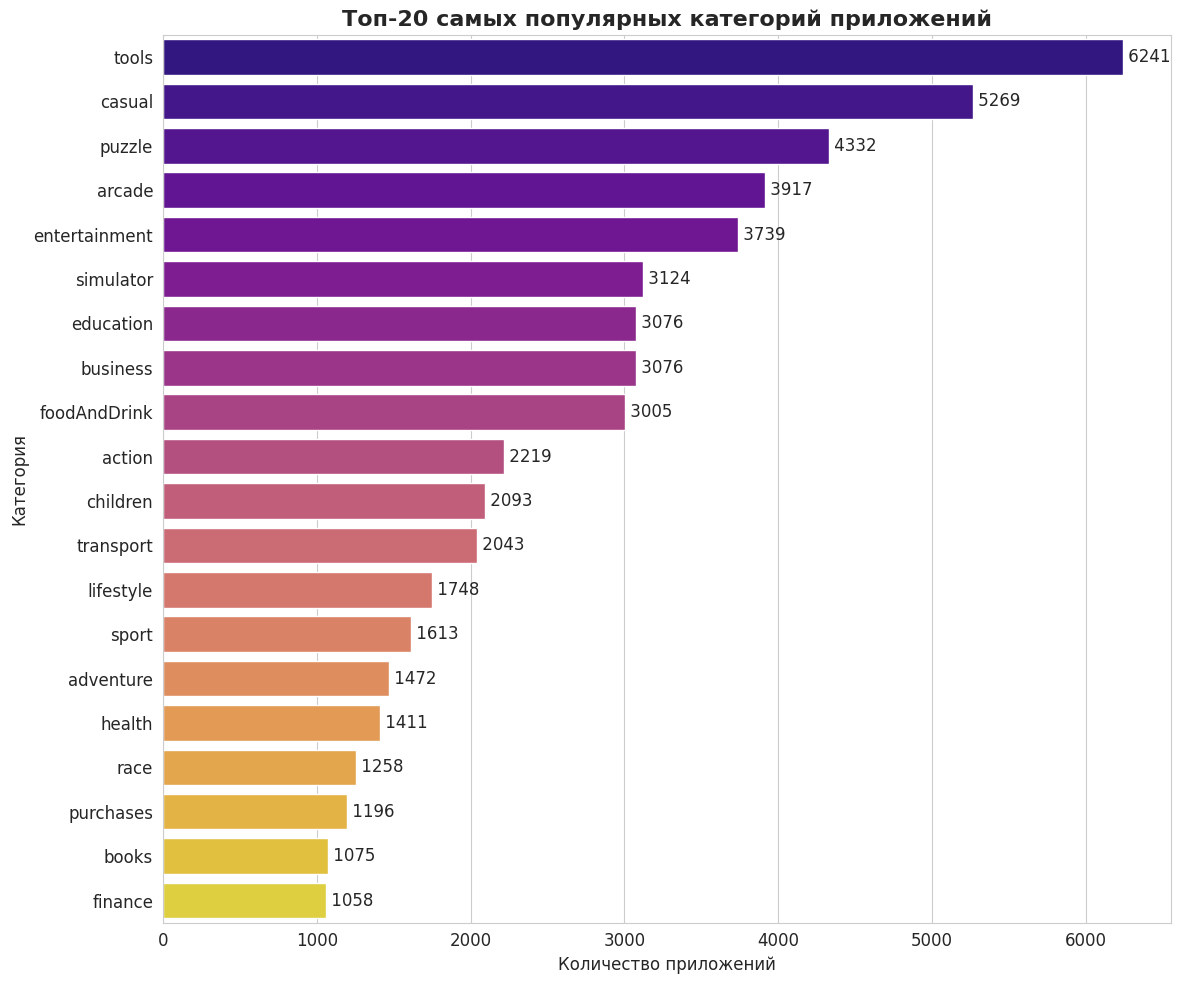

In [ ]:
# График самых популярных категорий

plt.figure(figsize=(12, 10))
sns.barplot(x="Количество", y="Категория", data=labels_df.head(20), palette="plasma", hue="Категория", legend=False)
plt.title("Топ-20 самых популярных категорий приложений", fontsize=16, fontweight='bold')
plt.xlabel("Количество приложений", fontsize=12)
plt.ylabel("Категория", fontsize=12)
for index, value in enumerate(labels_df.head(20)['Количество']):
    plt.text(value, index, f' {value}', va='center')
plt.tight_layout()
plt.show()

In [ ]:
display(labels_df.head(30).style.set_caption("Топ-30 самых популярных категорий и их доля").background_gradient(cmap='summer_r', subset=['Количество']))

,Категория,Количество,Доля_%
0,tools,6241,11.670000
1,casual,5269,9.850000
2,puzzle,4332,8.100000
3,arcade,3917,7.320000
4,entertainment,3739,6.990000
5,simulator,3124,5.840000
6,education,3076,5.750000
7,business,3076,5.750000
8,foodAndDrink,3005,5.620000
9,action,2219,4.150000


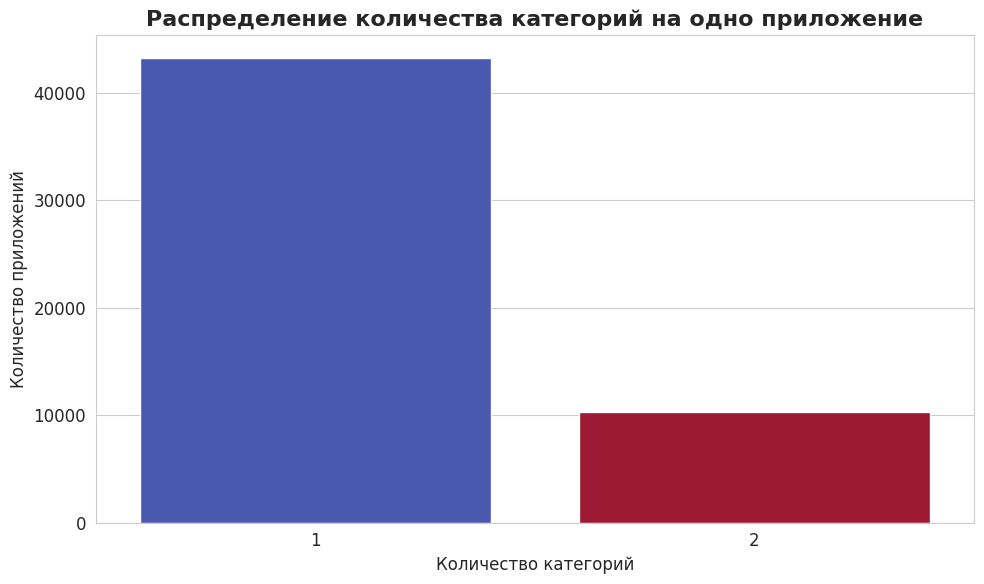

In [ ]:
# Гистограмма распределения количества меток

plt.figure(figsize=(10, 6))
sns.barplot(x="Категорий на приложение", y="Количество приложений", data=card_df, palette="coolwarm", hue="Категорий на приложение", legend=False)
plt.title("Распределение количества категорий на одно приложение", fontsize=16, fontweight='bold')
plt.xlabel("Количество категорий", fontsize=12)
plt.ylabel("Количество приложений", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
display(card_df.style.set_caption("Сколько приложений имеет N категорий").background_gradient(cmap='Blues', subset=['Количество приложений']))

,Категорий на приложение,Количество приложений,Доля_%
0,1,43207,80.770000
1,2,10287,19.230000


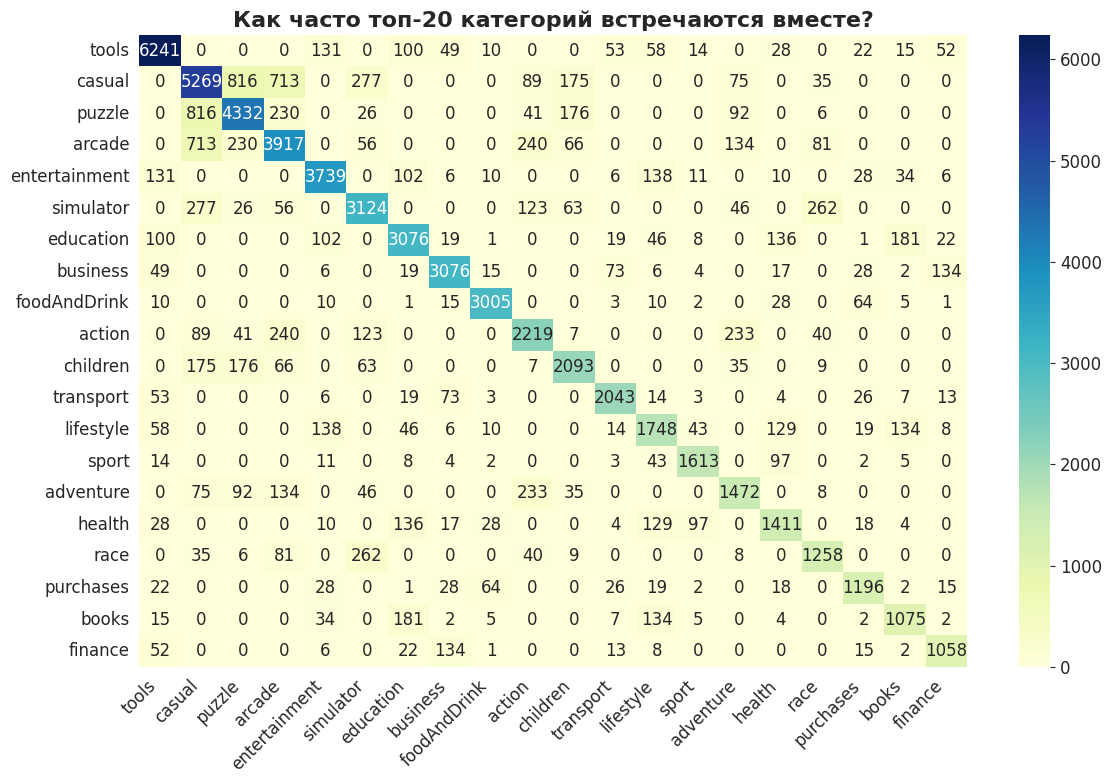

In [ ]:
# Еще давайте глянем на совместную встречаемость лейблов (Co-occurrence Matrix)

TOPN = 20 # Возьмем топ-20 категорий для наглядности
topN_labels = labels_df["Категория"].head(TOPN).tolist()
label_to_idx = {label: i for i, label in enumerate(topN_labels)}

co_occurrence_matrix = np.zeros((TOPN, TOPN), dtype=int)

for labels in df_train["labels_list"]:
    # Фильтруем метки, оставляя только те, что входят в наш топ
    top_labels_in_app = [l for l in labels if l in label_to_idx]
    # Проходим по всем парам меток в одном приложении
    for i in range(len(top_labels_in_app)):
        for j in range(i, len(top_labels_in_app)):
            idx1 = label_to_idx[top_labels_in_app[i]]
            idx2 = label_to_idx[top_labels_in_app[j]]
            co_occurrence_matrix[idx1, idx2] += 1
            # Матрица симметрична, поэтому заполняем и вторую половину
            if idx1 != idx2:
                co_occurrence_matrix[idx2, idx1] += 1

plt.figure(figsize=(12, 8))
sns.heatmap(co_occurrence_matrix, annot=True, fmt="d", cmap="YlGnBu",
            xticklabels=topN_labels, yticklabels=topN_labels)
plt.title(f"Как часто топ-{TOPN} категорий встречаются вместе?", fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

После небольшого EDA (разведочного анализа данных), давайте перейдем к подготовке данных: текста и лейблов.


In [ ]:
# Склеиваем текст (название + короткое + полное описание)

def build_text(row):
    parts = [
        str(row.get("app_name") or ""),
        str(row.get("shortDescription") or ""),
        str(row.get("full_description") or ""),
    ]
    txt = " ".join(p.strip() for p in parts if p).strip()
    return " ".join(txt.split())  # нормализуем пробелы

df_train["text"] = df_train.apply(build_text, axis=1)

мультибинаризация меток

In [ ]:
mlb = MultiLabelBinarizer()
Y = mlb.fit_transform(df_train["labels_list"])
labels = mlb.classes_.tolist()
NUM_LABELS = len(labels)

with open("labels.json", "w", encoding="utf-8") as f:
    json.dump(labels, f, ensure_ascii=False, indent=2)

print("Число меток:", NUM_LABELS)
print("Пример меток:", labels[:10])

Число меток: 45
Пример меток: ['action', 'adsAndServices', 'adventure', 'ar', 'arcade', 'board', 'boardAndCard', 'books', 'business', 'card']


Что делает [MultiLabelBinarizer](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MultiLabelBinarizer.html)?

Это удобный "кодировщик" для многометочных задач: у каждого приложения есть список категорий (например, `["tools", "puzzle"]`), а модели нужен числовой вектор фиксированной длины.

`MultiLabelBinarizer()` строит словарь всех встречающихся меток и переводит каждый список в мульти-хот-вектор: 1 - метка присутствует, 0 - нет. Порядок столбцов (классов) фиксируется внутри объекта `mlb` (мы сохраняем его в `labels.json`), поэтому на инференсе важно использовать тот же порядок, чтобы правильно вернуть названия категорий из индексов. Обратное преобразование делается через `mlb.inverse_transform(...)`, а список классов доступен в `mlb.classes_`.

In [ ]:
MODEL_ID = "sergeyzh/BERTA"
MAX_LEN = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

def tokenize_texts(texts):
    return tokenizer(texts, truncation=True, padding=False, max_length=MAX_LEN)

# простой сплит
tr_texts, val_texts, tr_y, val_y = train_test_split(
    df_train["text"].tolist(), Y, test_size=0.3, random_state=42
)

tr_enc = tokenize_texts(tr_texts)
val_enc = tokenize_texts(val_texts)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/732 [00:00<?, ?B/s]

In [ ]:

class Dataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels=None):
        self.enc = encodings
        self.labels = labels
    def __len__(self):
        return len(self.enc["input_ids"])
    def __getitem__(self, i):
        item = {k: torch.tensor(v[i]) for k, v in self.enc.items()}
        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[i]).float()
        return item

train_ds = Dataset(tr_enc, tr_y)
val_ds = Dataset(val_enc, val_y)
collator = DataCollatorWithPadding(tokenizer)

### Модель: BERT + "голова" для multi-label

Теперь, когда все данные подготовлены, мы наконец-то можем собрать и обучить нашу модель. Этот процесс состоит из четырех основных этапов:

1. Сборка модели. Мы берем предобученную "тушку" `BERT` и прикрепляем к ней "голову" для нашей конкретной задачи.

2. Создание "линейки". Мы пишем функцию для подсчета нашей метрики `Hitrate@3`, чтобы понимать, насколько хорошо модель справляется.

3. Настройка "режима тренировки". Мы задаем все параметры обучения - сколько эпох учиться, с какой скоростью, какими порциями и т.д.

4. Запуск "тренера". Мы передаем все компоненты специальному объекту `Trainer`, который берет всю сложную работу на себя.

**Собираем нашу модель**

Используем `AutoModelForSequenceClassification` - это специальный класс из Hugging Face, который делает именно то, что нам нужно: берет базовую модель-трансформер (наш `MODEL_ID`) и автоматически добавляет сверху один слой-классификатор (ту самую "голову").

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_ID,
    num_labels=NUM_LABELS,
    problem_type="multi_label_classification",  # включает BCEWithLogitsLoss + sigmoid - вот тут
)

config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/513M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sergeyzh/BERTA and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


**Готовим "линейку" для оценки**

`Trainer`'у нужно объяснить, как считать качество модели во время валидации. Для этого мы пишем две функции:

- `hitrate_at_k`: основная логика, которая считает `Hitrate@3`. Она берет сырые выходы модели (логиты), находит 3 самых вероятных предсказания и проверяет, есть ли среди них хотя бы одно правильное.

- `compute_metrics`: простая "обертка", которая получает от `Trainer`'а предсказания и правильные метки и передает их в нашу функцию `hitrate_at_k`.

In [ ]:
def hitrate_at_k(logits, y_true, k = 3):
    topk = np.argpartition(-logits, kth=k-1, axis=1)[:, :k]
    hits = 0
    for i in range(len(y_true)):
        true_idx = np.where(y_true[i] > 0)[0]
        if len(set(true_idx) & set(topk[i])) > 0:
            hits += 1
    return hits / len(y_true)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    return {"H@3": hitrate_at_k(logits, labels, k=3)}

**Настраиваем режим тренировки**

Здесь мы создаем объект `TrainingArguments`, который, как чек-лист, хранит все параметры для нашего тренера: куда сохранять модель, сколько эпох учить, с какой скоростью, какие использовать размеры батчей и т.д.

In [ ]:
!nvidia-smi

Sat Oct  4 18:09:56 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             10W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:512"
#os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [ ]:
torch.cuda.empty_cache()
fp16_ok = torch.cuda.is_available() # Проверяем, доступен ли GPU для ускорения вычислений

args = TrainingArguments(
    output_dir="bert_baseline",
    per_device_train_batch_size=16, # Размер батча для обучения
    per_device_eval_batch_size=32, # Размер батча для валидации
    num_train_epochs=2, # Сколько раз "прогнать" все данные
    learning_rate=2e-5, # Скорость обучения. Стандартное значение для Бертов
    weight_decay=0.01, # Параметр регуляризации для предотвращения переобучения
    logging_steps=500,
    save_steps=1000,
    do_eval=True,
    bf16=fp16_ok, # Использовать 16-битную точность для ускорения (если есть GPU)
    report_to="none",
    seed=42,
)

# Создаем объект Trainer, передавая ему все, что мы подготовили
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    data_collator=collator, # Инструмент для создания батчей (с паддингом)
    compute_metrics=compute_metrics
)

# Запускаем обучение
trainer.train()

# Опционально - можно сохранить модельку
# trainer.save_model("bert_baseline/best")
# tokenizer.save_pretrained("bert_baseline/best")

Step,Training Loss
500,0.077300
1000,0.058100
1500,0.051900
2000,0.049600
2500,0.046500
3000,0.043200
3500,0.042900
4000,0.041700
4500,0.042000


TrainOutput(global_step=4682, training_loss=0.050003138936925574, metrics={'train_runtime': 4655.6543, 'train_samples_per_second': 16.086, 'train_steps_per_second': 1.006, 'total_flos': 9848337814430262.0, 'train_loss': 0.050003138936925574, 'epoch': 2.0})

### Инференс и сабмит

"Инференс" (inference) - это просто стильное словечко, которое означает "применение обученной модели" к новым данным, которых она раньше не видела. Наша модель готова, и теперь мы применим ее к тестовой выборке (`test.tsv`), чтобы получить предсказания и сформировать итоговый файл.

In [ ]:
# загружаем тест
df_test = pd.read_csv("/content/drive/My Drive/test.tsv", sep="\t")
df_test["text"] = df_test.apply(build_text, axis=1)

# токенизируем
te_enc = tokenize_texts(df_test["text"].tolist())
test_ds = Dataset(te_enc, labels=None)

# предсказания (логиты)
pred_logits = trainer.predict(test_ds).predictions

# берём top-3 меток и сортируем их по убыванию уверенности
id2label = np.array(labels)
top3_idx = np.argpartition(-pred_logits, kth=2, axis=1)[:, :3]

# упорядочим эти три по логитам
ordered = np.take_along_axis(
    top3_idx,
    np.argsort(-np.take_along_axis(pred_logits, top3_idx, axis=1), axis=1),
    axis=1
)

# gреобразуем отсортированные индексы в строки с метками, разделенными '|'
pred_top3 = ["|".join(id2label[row]) for row in ordered]

# DataFrame для сабмита
submission = pd.DataFrame({
    "app_name": df_test["app_name"],
    "labels_str": pred_top3
})
submission.head()

,app_name,labels_str
0,Lemon clicker,casual|arcade|simulator
1,Memo Английский язык,education|tools|books
2,Slave Man Rescue,adventure|puzzle|action
3,Taking Care of Granny,puzzle|casual|children
4,Escape From Classic Room,puzzle|casual|arcade


In [ ]:
submission.to_csv("/content/drive/My Drive/submission.tsv", sep="\t", index=False)


In [ ]:
# Проверяем, что формат совпадает с образцом
sample = pd.read_csv("/content/drive/My Drive/sample_submission.tsv", sep="\t")
assert list(submission.columns) == ["app_name", "labels_str"]

print("Размер сабмита:", submission.shape)

Размер сабмита: (15046, 2)


Итак, мы обучили нашу модель `sergeyzh/BERTA` и получили финальные результаты. И заняли высокое место, получив 0.93 по нашей метрике?
